# Error Correction Model Parameter Scan

Consider two cointegrated time series, $X_t \sim I(1)$ and $Y_t \sim I(1)$. The Error Correction Model is given by,

$
\begin{align}
\Delta Y_t = \delta + \gamma \Delta X_t + \lambda \left( Y_{t-1} - \alpha - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{11}
$

For simplicity it will be assumed that $\alpha = \delta = 0$ giving,

$
\begin{align}
\Delta Y_t = \gamma \Delta X_t + \lambda \left( Y_{t-1} - \beta X_{t-1} \right) + \nu_t
\end{align}
\tag{12}
$

Here the behavior of solutions to the ECM will be discussed as the parameters $\beta$, $\lambda$ and $\gamma$ are variated. Also, the variation in the $\text{AR}(1)$ coefficient $\varphi$, used in the simulation of $X_t$ will be considered.

## Mean Variance and Covariance

The mean, variance and variance of the ECM variable $X_t$ is given by,

$
\begin{align}
\text{E}\left[ X_t\right] &= 0 \\
\text{Var}\left[ X_t\right] &= \frac{\sigma^2}{1 - \varphi^2}\left[t + 2 \sum_{k=1}^t \left(t - k\right) \varphi^k \right]
\end{align}
\tag{14}
$

and for $Y_t$,

$
\begin{align}
\text{E}\left[ Y_t\right] &= 0 \\
\text{Var}\left[ Y_t\right] &= \beta^2 \text{Var}\left[ X_t\right]
\end{align}
\tag{15}
$

Finally the covariance of $X_t$ and $Y_t$ is given by,

$
\begin{align}
\text{Cov}\left[X_t Y_t\right] &= \beta \text{Var}\left[ X_t\right]
\end{align}
\tag{16}
$

In [79]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ecm, stats, adf, arima
from lib.plots import ecm_beta, comparison, curve

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def ecm_comparison_plot(xt, yt, φ, β, γ, λ, σ=1.0):
    title = f"ECM Simulation: φ={φ}, β={β}, γ={γ}, λ={λ}, σ={σ}"
    εt = yt - β * xt
    labels = [r"$x_t$", r"$y_t$", r"$\hat{\varepsilon}=y_t - \hat{\beta}x_t$"]
    comparison([xt, yt, εt], title=title, ylabel=r"$S_t$", xlabel=r"$t$", labels=labels, lw=1)

## $\beta$ Scan

Insight into variation of $\beta$ can be determined by inspecting expressions for the variance and covariance for $X_t$ and $Y_t$. First consider the variance,

$
\begin{align}
\text{E}\left[ Y_t\right] &= 0 \\
\text{Var}\left[ Y_t\right] &= \beta^2 \text{Var}\left[ X_t\right]
\end{align}
\tag{15}
$

For $|\beta| \gt 1$ it follows that $\text{Var}\left[ Y_t\right] \gt \text{Var}\left[ X_t\right]$, for $|\beta| \lt 1$ it follows that $\text{Var}\left[ Y_t\right] \lt \text{Var}\left[ X_t\right]$ and if $|\beta| = 1$ the variances of $X_t$ and $Y_t$ are equal. From the covariance relationship,

$
\begin{align}
\text{Cov}\left[X_t Y_t\right] &= \beta \text{Var}\left[ X_t\right]
\end{align}
\tag{16}
$

it is seen for $\beta \gt 0$ that $X_t$ and $Y_t$ are correlated, for $\beta \lt 0$ they are negatively correlated and if $\beta = 0$ they are uncorrelated.

In [3]:
φ = 0.5
λ = -0.5
γ = 0.5
npts = 1000

### $\beta=0$

$X_t$ and $Y_t$ are uncorrelated as seen in the regression plot and $\varepsilon_{t-1} = Y_{t-1} - \beta X_{t-1}$ implies that $\varepsilon_{t-1} = Y_{t-1}$

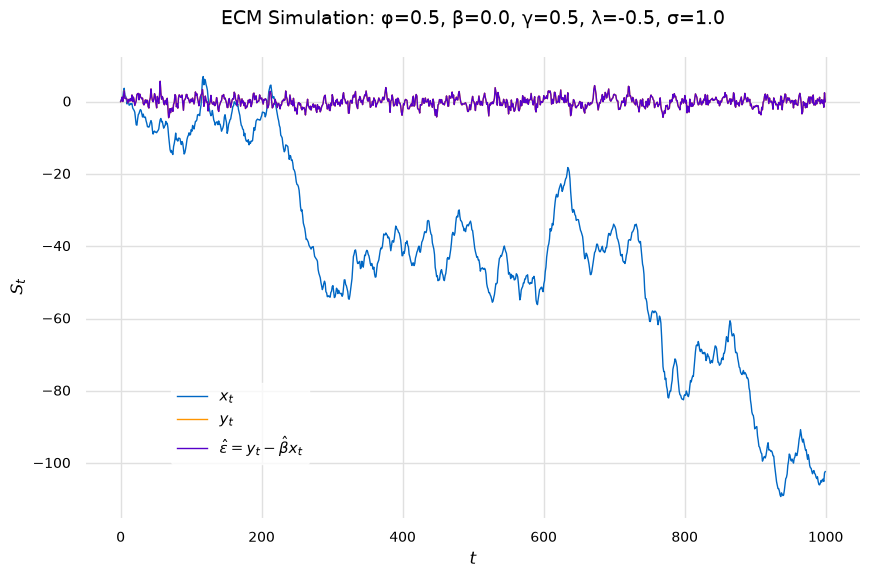

In [4]:
β = 0.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [5]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     14.39
Date:                Sun, 23 Aug 2026   Prob (F-statistic):           0.000157
Time:                        16:05:18   Log-Likelihood:                -1752.1
No. Observations:                1000   AIC:                             3508.
Df Residuals:                     998   BIC:                             3518.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1963      0.079      2.476      0.013       0.041       0.352
x1             0.0058      0.002      3.794      0.000       0.003       0.009
==============================================================================
Omnibus:                        4.303   Durbin-Watson:                   0.801
Prob(Omnibus):                  0.116   Jarque-Bera (JB):                4.994
Skew:                          -0.041   Prob(JB):                       0.0823
Kurtosis:                       3.336   Cond. No.                         93.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

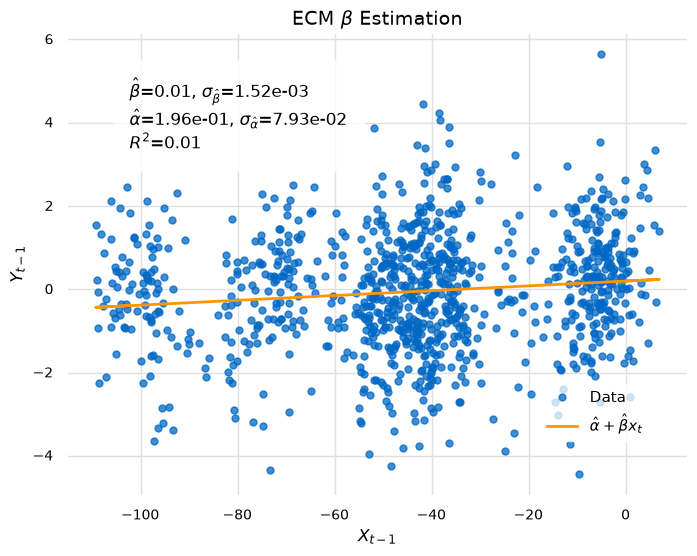

In [6]:
ecm_beta(yt, result_model, xt)

### $\beta=1$

$X_t$ and $Y_t$ correlated with equal variance

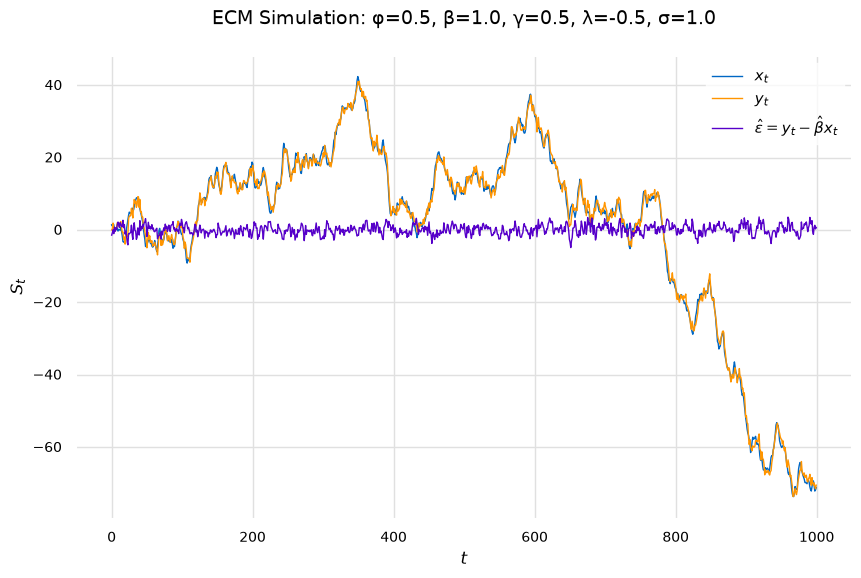

In [7]:
β = 1.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [8]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 3.921e+05
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:19   Log-Likelihood:                -1710.3
No. Observations:                1000   AIC:                             3425.
Df Residuals:                     998   BIC:                             3434.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0753      0.042      1.778      0.076      -0.008       0.158
x1             0.9943      0.002    626.151      0.000       0.991       0.997
==============================================================================
Omnibus:                        2.231   Durbin-Watson:                   0.875
Prob(Omnibus):                  0.328   Jarque-Bera (JB):                2.289
Skew:                          -0.112   Prob(JB):                        0.318
Kurtosis:                       2.930   Cond. No.                         26.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

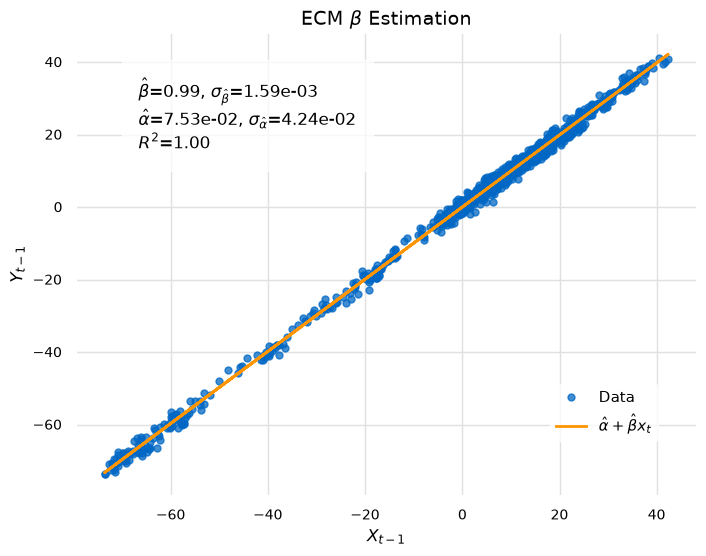

In [9]:
ecm_beta(yt, result_model, xt)

### $\beta=-1$

$X_t$ and $Y_t$ uncorrelated with equal variance.

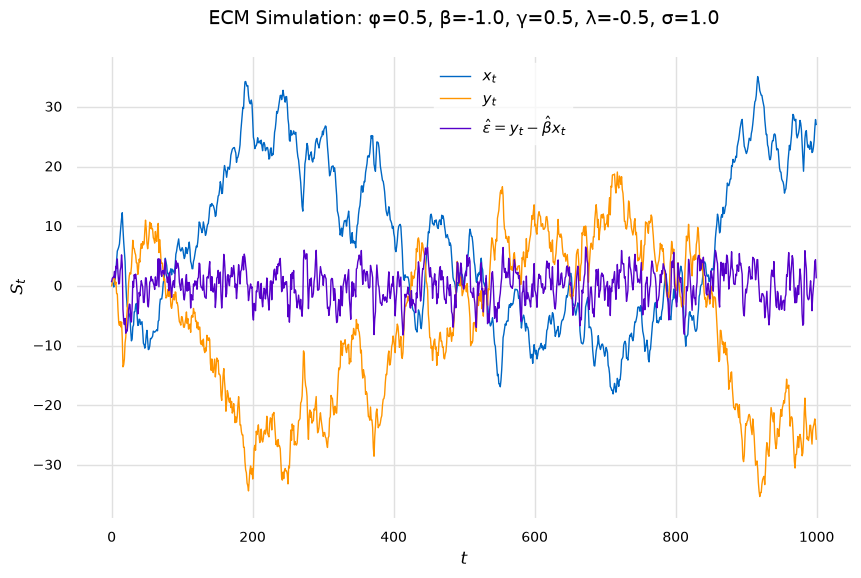

In [10]:
β = -1.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [11]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                 2.213e+04
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:19   Log-Likelihood:                -2454.5
No. Observations:                1000   AIC:                             4913.
Df Residuals:                     998   BIC:                             4923.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0169      0.101     -0.168      0.867      -0.215       0.181
x1            -0.9819      0.007   -148.766      0.000      -0.995      -0.969
==============================================================================
Omnibus:                       16.703   Durbin-Watson:                   0.506
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               16.256
Skew:                          -0.280   Prob(JB):                     0.000295
Kurtosis:                       2.723   Cond. No.                         17.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

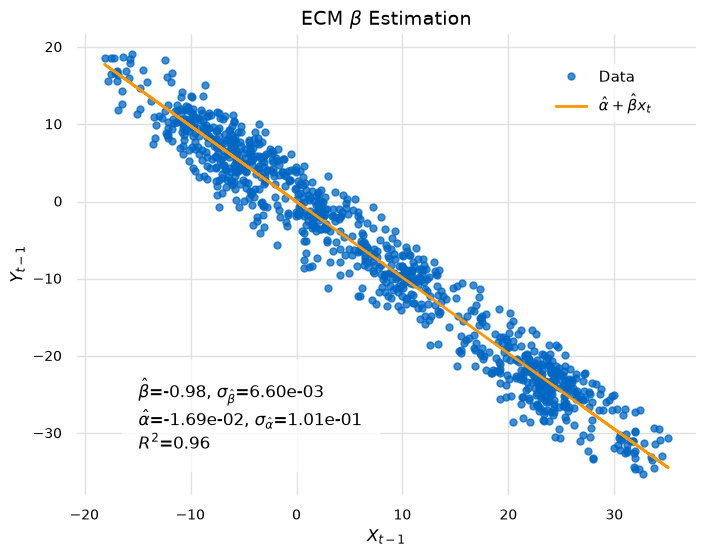

In [12]:
ecm_beta(yt, result_model, xt)

### $\beta \lt 0$, $\beta \gt 0$ and $|\beta | \lt 1$

The first plots show $\beta \lt 0$ where $X_t$ and $Y_t$ are uncorrelated and $\text{VAR}\left[X_t\right] > \text{VAR}\left[Y_t\right]$ and second plots show $\beta \gt 0$ where $X_t$ and $Y_t$ are correlated and $\text{VAR}\left[X_t\right] > \text{VAR}\left[Y_t\right]$ 

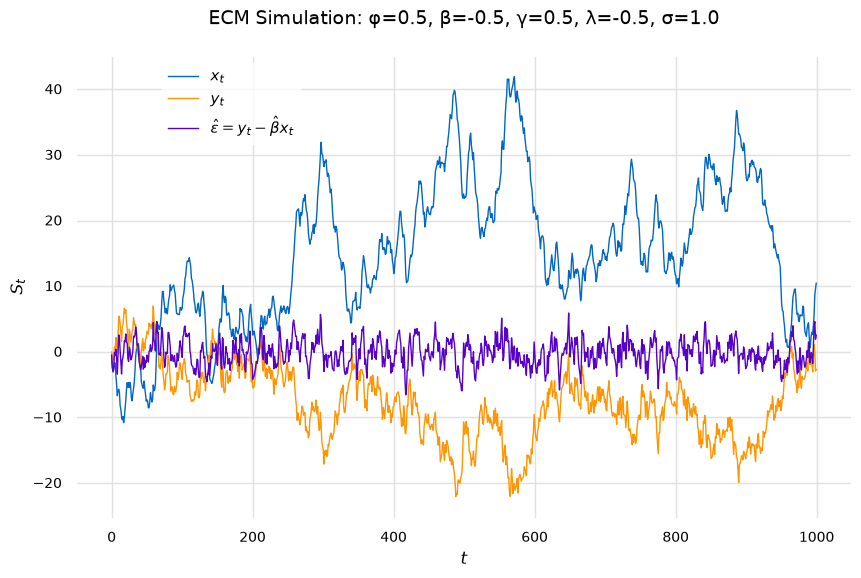

In [13]:
β = -0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [14]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.877
Method:                 Least Squares   F-statistic:                     7128.
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:19   Log-Likelihood:                -2091.1
No. Observations:                1000   AIC:                             4186.
Df Residuals:                     998   BIC:                             4196.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4237      0.107     -3.972      0.000      -0.633      -0.214
x1            -0.4828      0.006    -84.430      0.000      -0.494      -0.472
==============================================================================
Omnibus:                        0.470   Durbin-Watson:                   0.631
Prob(Omnibus):                  0.791   Jarque-Bera (JB):                0.557
Skew:                           0.002   Prob(JB):                        0.757
Kurtosis:                       2.884   Cond. No.                         32.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

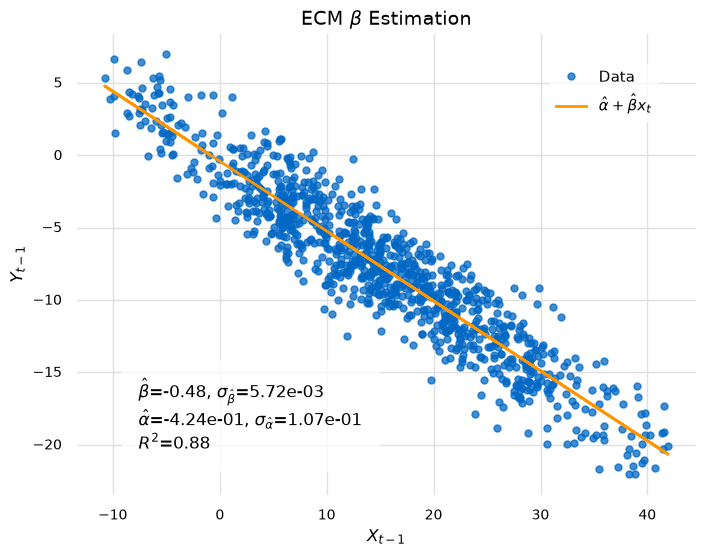

In [15]:
ecm_beta(yt, result_model, xt)

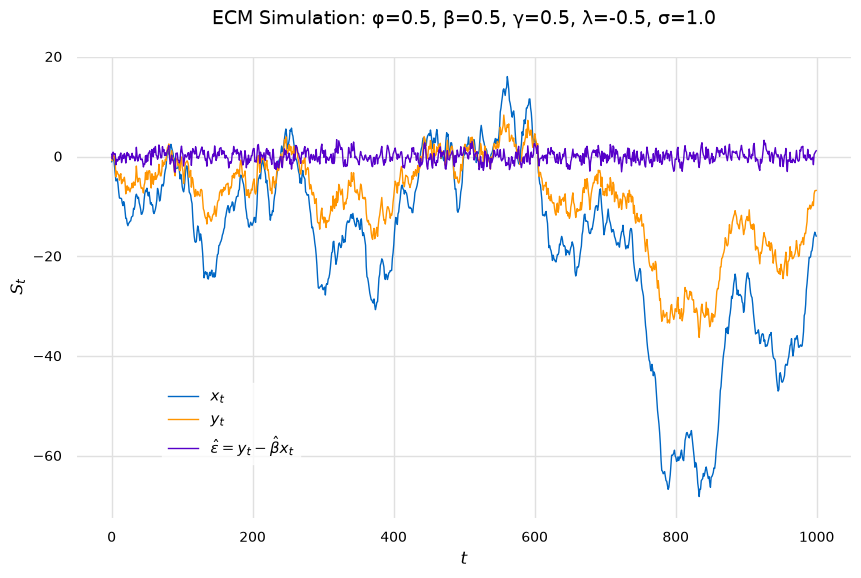

In [16]:
β = 0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [17]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 6.425e+04
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:19   Log-Likelihood:                -1565.6
No. Observations:                1000   AIC:                             3135.
Df Residuals:                     998   BIC:                             3145.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0317      0.051      0.626      0.531      -0.068       0.131
x1             0.4989      0.002    253.483      0.000       0.495       0.503
==============================================================================
Omnibus:                        1.773   Durbin-Watson:                   0.983
Prob(Omnibus):                  0.412   Jarque-Bera (JB):                1.711
Skew:                          -0.038   Prob(JB):                        0.425
Kurtosis:                       2.812   Cond. No.                         35.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

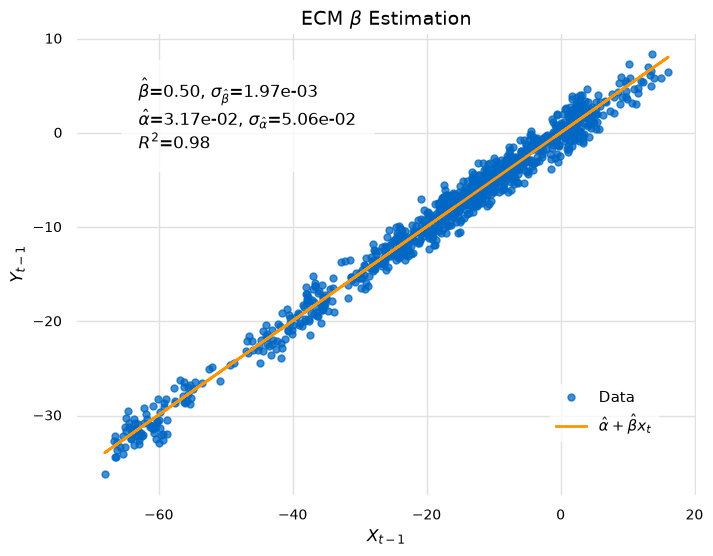

In [18]:
ecm_beta(yt, result_model, xt)

### $\beta \lt 0$, $\beta \gt 0$ and $|\beta | \gt 1$

The first plots show $\beta \lt 0$ where $X_t$ and $Y_t$ are uncorrelated and $\text{VAR}\left[X_t\right] < \text{VAR}\left[Y_t\right]$ and second plots show $\beta \gt 0$ where $X_t$ and $Y_t$ are correlated and $\text{VAR}\left[X_t\right] < \text{VAR}\left[Y_t\right]$ 

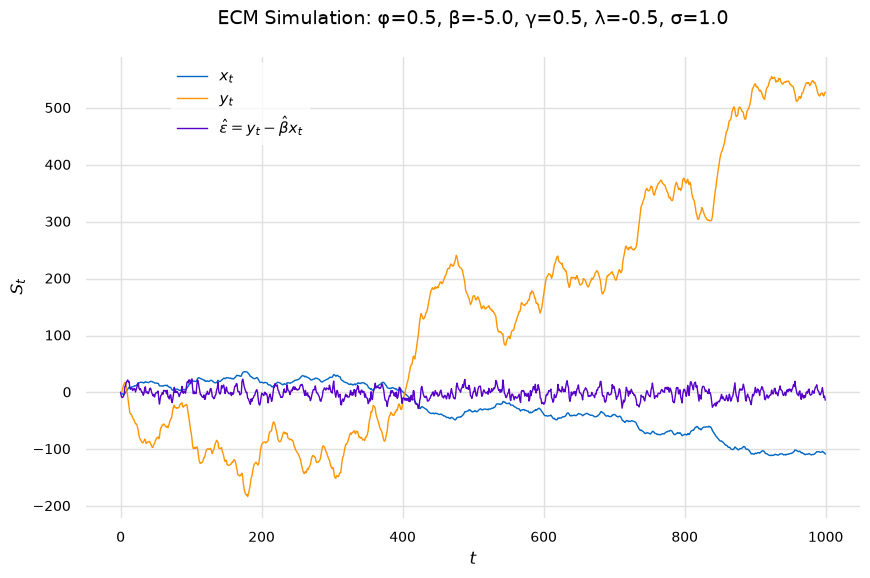

In [19]:
β = -5.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [20]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 5.835e+05
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:19   Log-Likelihood:                -3632.3
No. Observations:                1000   AIC:                             7269.
Df Residuals:                     998   BIC:                             7278.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6418      0.344     -1.866      0.062      -1.317       0.033
x1            -4.9801      0.007   -763.891      0.000      -4.993      -4.967
==============================================================================
Omnibus:                        0.779   Durbin-Watson:                   0.412
Prob(Omnibus):                  0.677   Jarque-Bera (JB):                0.843
Skew:                          -0.063   Prob(JB):                        0.656
Kurtosis:                       2.933   Cond. No.                         62.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

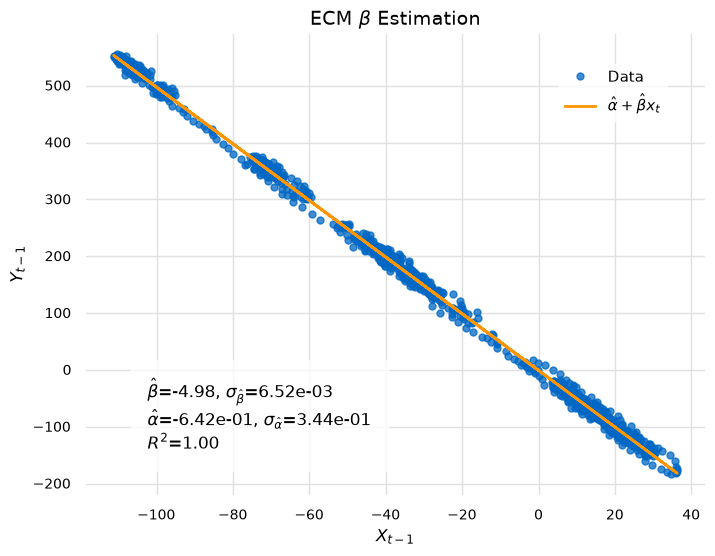

In [21]:
ecm_beta(yt, result_model, xt)

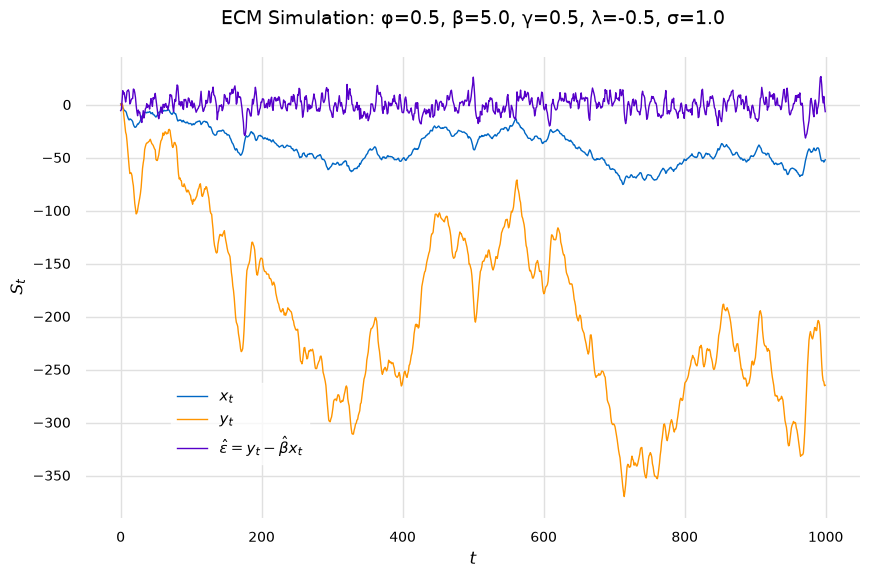

In [22]:
β = 5.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [23]:
result, result_model = ecm.compute_beta_estimate(yt, xt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.096e+05
Date:                Sun, 23 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:05:20   Log-Likelihood:                -3494.1
No. Observations:                1000   AIC:                             6992.
Df Residuals:                     998   BIC:                             7002.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0989      0.647     -0.153      0.879      -1.369       1.171
x1             4.9854      0.015    331.028      0.000       4.956       5.015
==============================================================================
Omnibus:                       24.034   Durbin-Watson:                   0.373
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.739
Skew:                          -0.278   Prob(JB):                     2.11e-07
Kurtosis:                       3.655   Cond. No.                         110.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

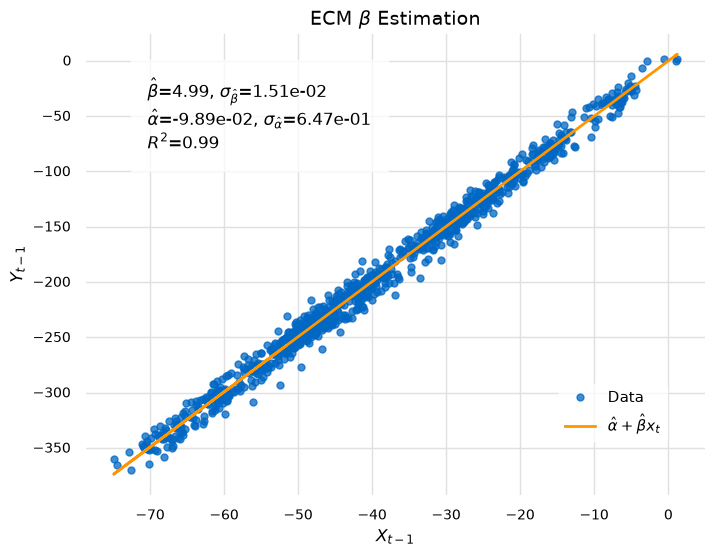

In [24]:
ecm_beta(yt, result_model, xt)

## $\lambda$ Scan

The values of $\lambda$ and $\gamma$ measure the relative weighting of the $\Delta X_t$ term and the error correction term, $Y_{t-1} - \beta X_{t-1}$.

Transitions in the qualitative behavior of simulations occur for the following values,

$
\begin{align}
\lambda = 0, -\frac{3}{2}, -2
\end{align}
\tag{16}
$

### $\lambda \ge 0$

For the interval $\lambda \ge 0$ the $\lambda\left(Y_{t-1} - \beta X_{t-1}\right)$ term is positive for $Y_{t-1} > \beta X_{t-1}$ and negative for $Y_{t-1} < \beta X_{t-1}$ This will drive $Y_t$ away from $\beta X_t$ instead of toward it. This is illustrated in the first two simulations where $\lambda$ is very small and quickly $Y_t$ grows quickly diverging from $X_t$. For this case the residual is not stationary as demonstrated below for $\lambda=0$ and $\lambda=0.0025$.

In [25]:
β = 5.0
φ = 0.5
γ = 0.5

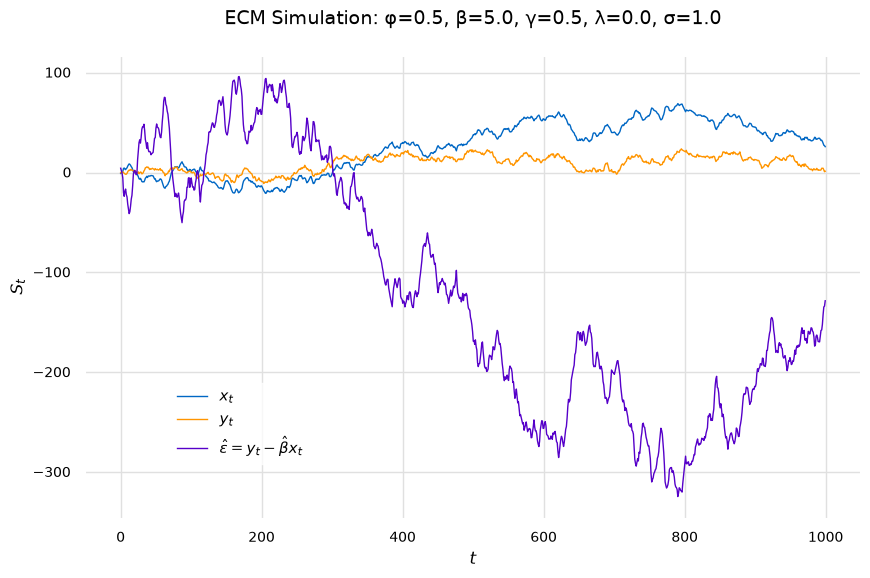

In [26]:
λ = 0.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [27]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.576399 │
├────────────────┼────────────┤
│ pvalue         │   0.464483 │
├────────────────┼────────────┤
│ Lags           │   4        │
├────────────────┼────────────┤
│ Number Obs     │ 995        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


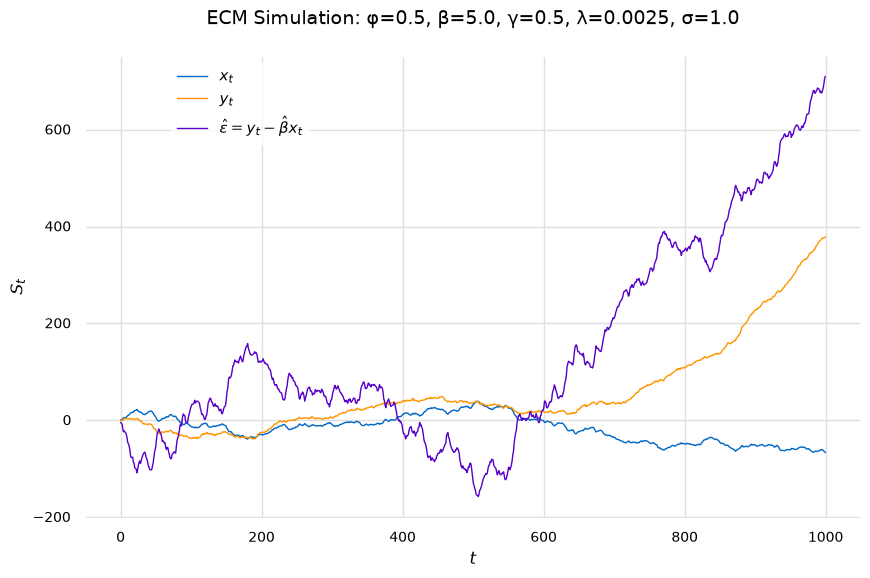

In [28]:
λ = 0.0025
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [29]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   2.54077  │
├────────────────┼────────────┤
│ pvalue         │   0.998397 │
├────────────────┼────────────┤
│ Lags           │   2        │
├────────────────┼────────────┤
│ Number Obs     │ 997        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


### $-\frac{3}{2} \le \lambda \lt 0$

For this interval the residual is stationary and $Y_t$ is driven toward $\beta X_t$ since $\lambda\left(Y_{t-1} - \beta X_{t-1}\right)$ is negative if $Y_{t-1} \gt \beta X_{t-1}$ positive if $Y_{t-1} \le \beta X_{t-1}$. Also, for this case the residual $\text{AR}(1)$ parameter $\varphi > 0$ indicating that it is serially correlated.

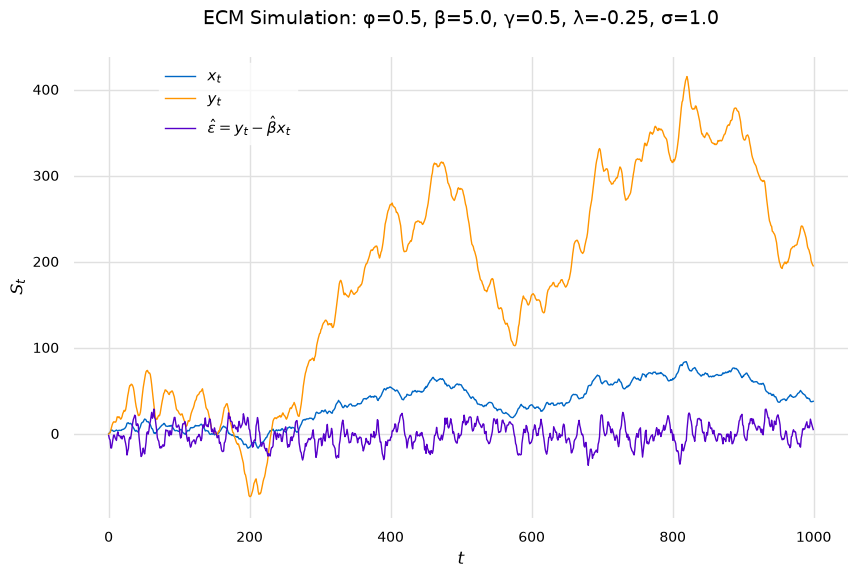

In [30]:
λ = -0.25
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [31]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │  -9.66179     │
├────────────────┼───────────────┤
│ pvalue         │   5.59355e-17 │
├────────────────┼───────────────┤
│ Lags           │   3           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [32]:
result, _ = arima.compute_ar_estimate(εt, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -3008.008
Date:                Sun, 23 Aug 2026   AIC                           6022.015
Time:                        16:05:20   BIC                           6036.738
Sample:                             0   HQIC                          6027.611
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7610      1.764     -0.431      0.666      -4.218       2.696
ar.L1          0.9122      0.013     70.208      0.000       0.887       0.938
sigma2        23.9592      1.061     22.589      0.000      21.880      26.038
===================================================================================
Ljung-Box (L1) (Q):                  93.27   Jarque-Bera (JB):                 0.19
Prob(Q):                              0.00   Prob(JB):                         0.91
Heteroskedasticity (H):               1.01   Skew:                             0.03
Prob(H) (two-sided):                  0.91   Kurtosis:                         3.04
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### $-2 \le \lambda \lt -\frac{3}{2}$

For this interval the residual is stationary and $Y_t$ is driven toward $\beta X_t$ since $\lambda\left(Y_{t-1} - \beta X_{t-1}\right)$ is negative if $Y_{t-1} \gt \beta X_{t-1}$ positive if $Y_{t-1} \le \beta X_{t-1}$. Also, for this case the residual $\text{AR}(1)$ parameter $\varphi \lt 0$ indicating that it is serially anticorrelated.

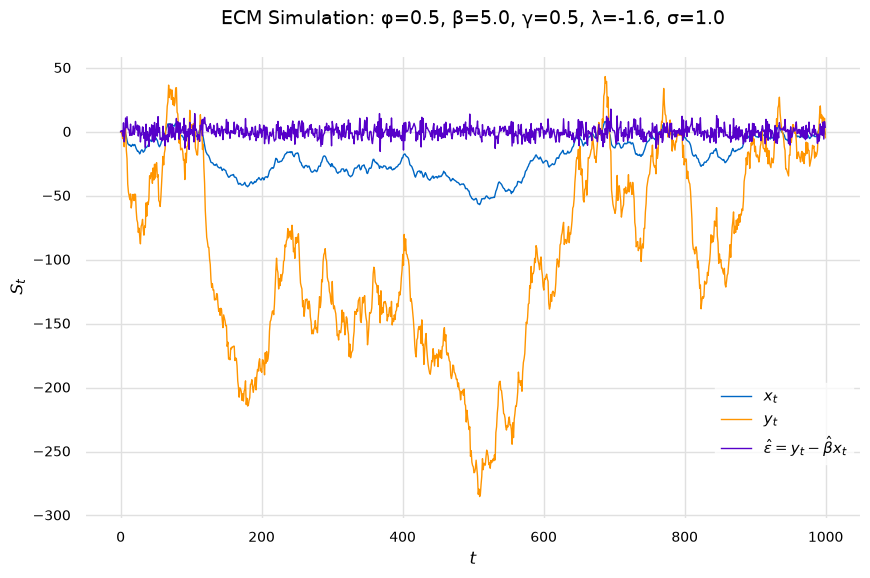

In [33]:
λ = -1.6
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [34]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.0156      │
├────────────────┼───────────────┤
│ pvalue         │   5.10719e-29 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [35]:
result, _ = arima.compute_ar_estimate(εt, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2987.890
Date:                Sun, 23 Aug 2026   AIC                           5981.781
Time:                        16:05:20   BIC                           5996.504
Sample:                             0   HQIC                          5987.377
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0109      0.128     -0.085      0.932      -0.262       0.240
ar.L1         -0.1919      0.030     -6.330      0.000      -0.251      -0.132
sigma2        23.0544      1.019     22.627      0.000      21.057      25.051
===================================================================================
Ljung-Box (L1) (Q):                   3.08   Jarque-Bera (JB):                 2.58
Prob(Q):                              0.08   Prob(JB):                         0.27
Heteroskedasticity (H):               0.99   Skew:                             0.12
Prob(H) (two-sided):                  0.96   Kurtosis:                         3.07
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### $-2 \ge \lambda$

For this interval the residual is stationary and $Y_t$ oscillates very rapidly.

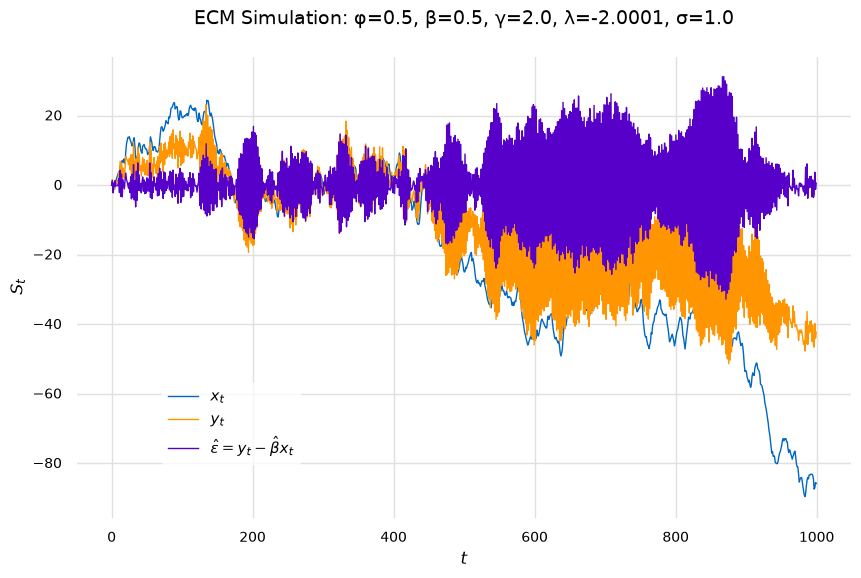

In [96]:
β = 0.5
φ = 0.5
γ = 2.0
λ = -2.0001
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [90]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤══════════╕
│ Test Statistic │ -984.969 │
├────────────────┼──────────┤
│ pvalue         │    0     │
├────────────────┼──────────┤
│ Lags           │    0     │
├────────────────┼──────────┤
│ Number Obs     │  999     │
╘════════════════╧══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [97]:
result, _ = arima.compute_ar_estimate(εt, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1422.011
Date:                Sun, 23 Aug 2026   AIC                           2850.023
Time:                        17:00:30   BIC                           2864.746
Sample:                             0   HQIC                          2855.619
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0218      0.016     -1.381      0.167      -0.053       0.009
ar.L1         -0.9995      0.001  -1115.073      0.000      -1.001      -0.998
sigma2         0.9992      0.043     23.229      0.000       0.915       1.084
===================================================================================
Ljung-Box (L1) (Q):                   0.73   Jarque-Bera (JB):                 1.33
Prob(Q):                              0.39   Prob(JB):                         0.51
Heteroskedasticity (H):               0.95   Skew:                             0.04
Prob(H) (two-sided):                  0.65   Kurtosis:                         3.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## $\gamma$ Scan

The $\gamma$ parameter determins the weighting between the two terms $\gamma \Delta X_t$ and $\lambda \left( Y_{t-1} - \beta X_{t-1} \right)$, since stationarity requires $0 \gt \lambda \gt -2$ it is expected that if $|\gamma| \gt |\lambda|$ that the $\gamma$ term will dominate. If $\gamma \lt 0$ changes in $X_t$ will cause changes in the opposite direction for $Y_t$. For $|\gamma| \gg |\lambda|$ changes in $X_t$ are amplified in changes in $Y_t$. This causes $Y_t$ to eventually dominate to that the residual approaches $Y_t$. Finally, the residual is stationary for all values $\gamma$

### $|\gamma| \lt |\lambda|$

In [100]:
β = 5.0
φ = 0.5
λ = -1.0

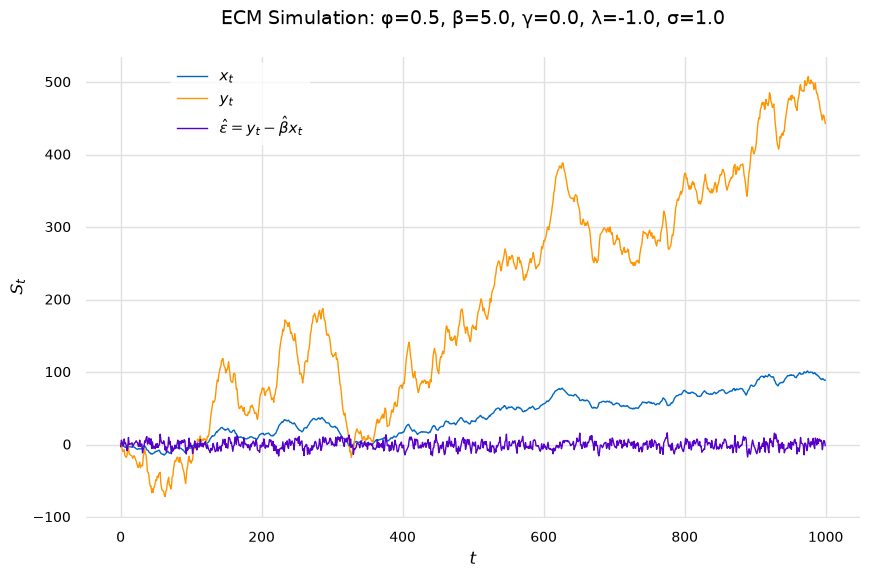

In [101]:
γ = 0.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [102]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -15.2905      │
├────────────────┼───────────────┤
│ pvalue         │   5.39159e-27 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


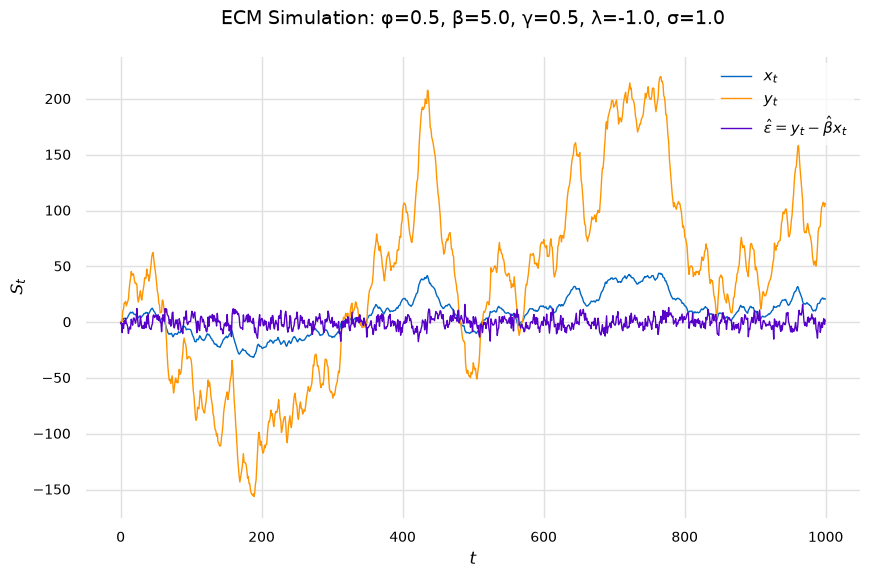

In [103]:
γ = 0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [104]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -14.0859      │
├────────────────┼───────────────┤
│ pvalue         │   2.01685e-25 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


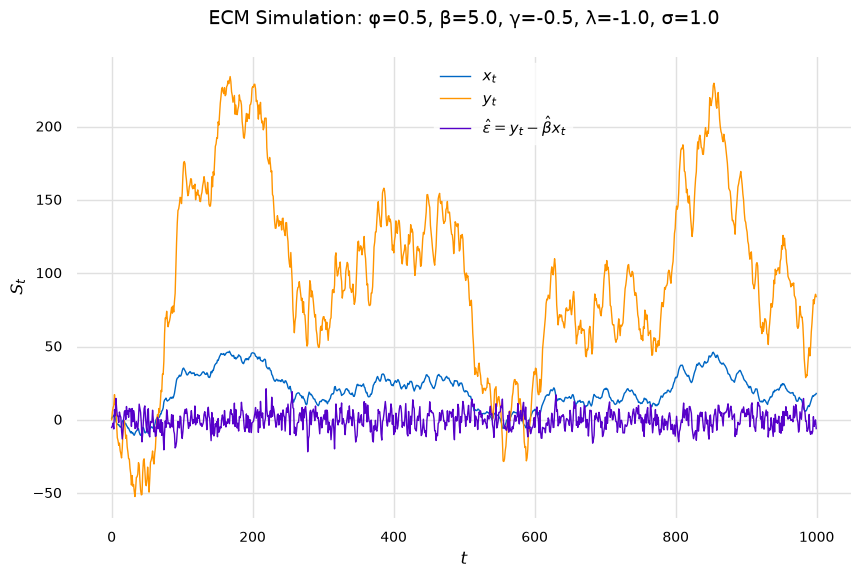

In [105]:
γ = -0.5
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [106]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -15.4697      │
├────────────────┼───────────────┤
│ pvalue         │   3.39937e-27 │
├────────────────┼───────────────┤
│ Lags           │   2           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


### $|\gamma| \gt |\lambda|$

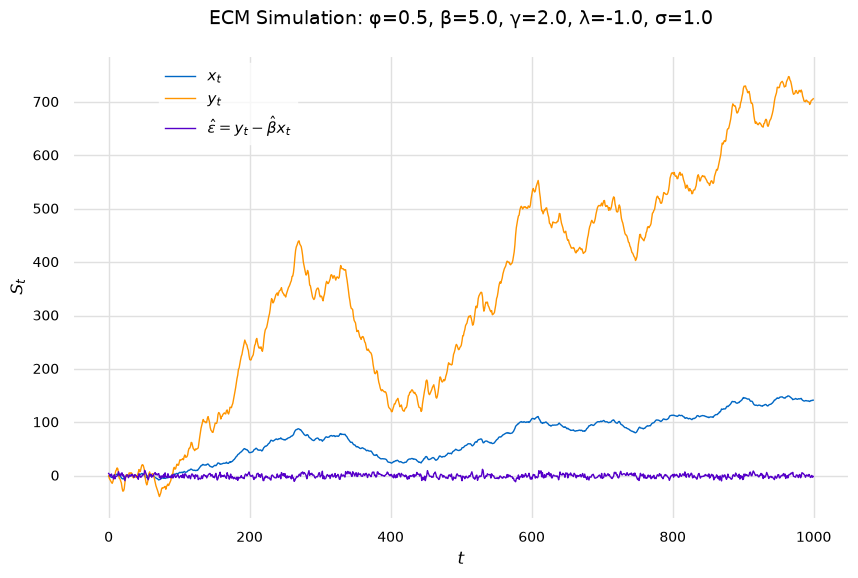

In [107]:
γ = 2.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [108]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -15.6807      │
├────────────────┼───────────────┤
│ pvalue         │   2.02794e-27 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


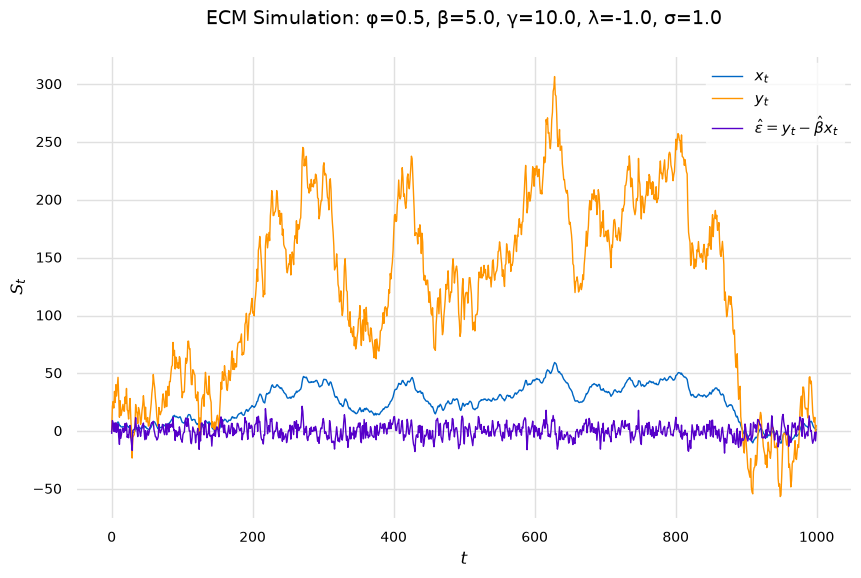

In [109]:
γ = 10.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [110]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.191       │
├────────────────┼───────────────┤
│ pvalue         │   4.52788e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


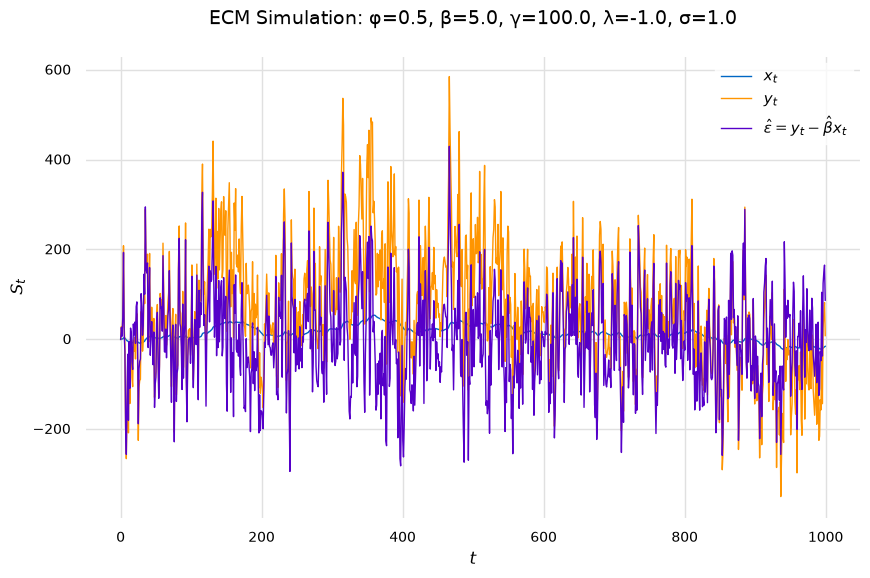

In [111]:
γ = 100.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [112]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -18.3165      │
├────────────────┼───────────────┤
│ pvalue         │   4.21145e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


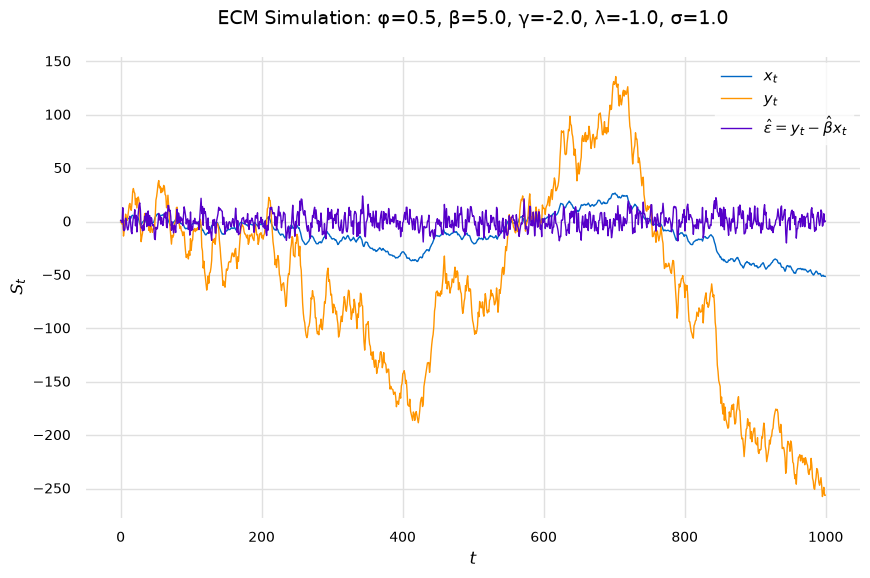

In [113]:
γ = -2.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [114]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤══════════╕
│ Test Statistic │ -19.5089 │
├────────────────┼──────────┤
│ pvalue         │   0      │
├────────────────┼──────────┤
│ Lags           │   0      │
├────────────────┼──────────┤
│ Number Obs     │ 999      │
╘════════════════╧══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


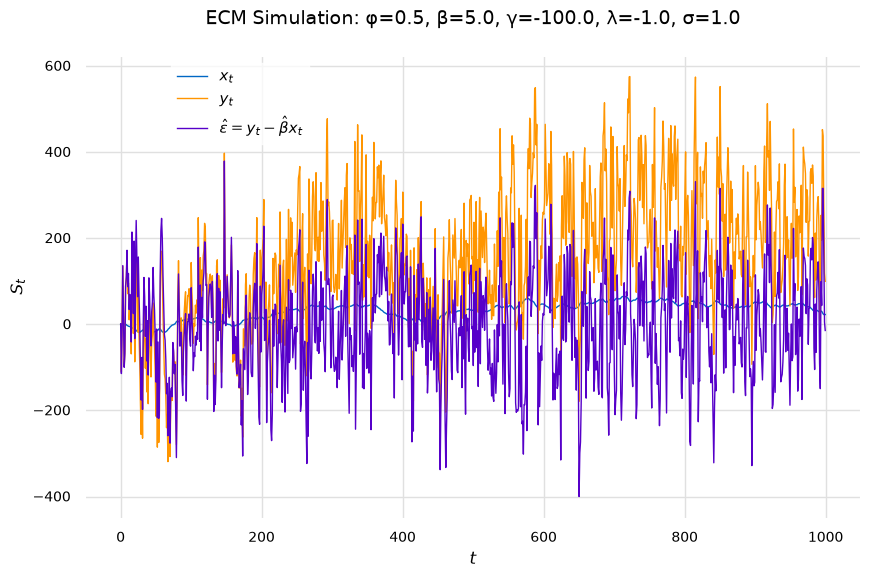

In [115]:
γ = -100.0
t, [xt, yt] = ecm.create_source(φ=φ, β=β, λ=λ, γ=γ, npts=npts)
ecm_comparison_plot(xt, yt, φ, β, γ, λ)

In [116]:
εt = yt - β * xt
result, _ = adf.compute_adf_test(εt)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.948       │
├────────────────┼───────────────┤
│ pvalue         │   5.38172e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 999           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
